In [1]:
import numpy as np
import netket as nk
import jax
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from scipy.ndimage import uniform_filter1d
import os
from tqdm import tqdm

In [2]:
N = 4
data_file = f"../data/N{N}/results_N{N}_vs_T.json"
with open(data_file, "r") as f:
    data = json.load(f)

T_array      = np.array(data["T"])
energy_results      = data["energy"]
entropy_results     = data["entropy"]
free_energy_results = data["free_energy"]
param_index  = data["param_index"]

In [3]:
from netket.operator.spin import sigmax, sigmaz

def hamiltonian_system_and_extended(Gamma, V, N, hi_system, hi_extended):
    H_system = 0
    H_extended = 0
    for i in range(N):
        H_system += Gamma * sigmax(hi_system, i)
        H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)
        H_extended += Gamma * sigmax(hi_extended, i)
        H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)
    return H_system, H_extended

Gamma = -1.5  
V = -1
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)
H_system, H_extended = hamiltonian_system_and_extended(Gamma, V, N, hi_system, hi_extended)

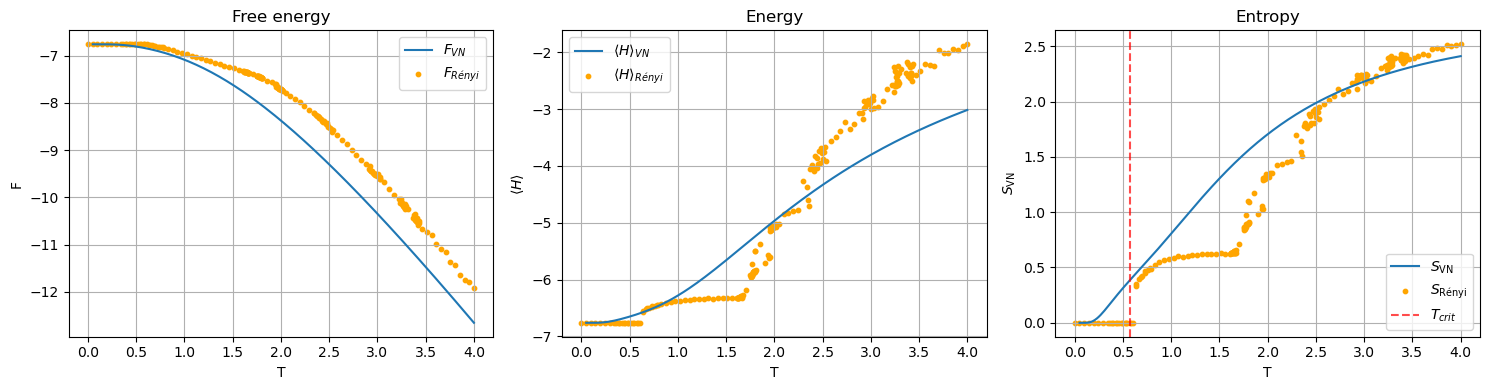

In [4]:
# --- Convertir H a matriz densa  ---
H_matrix = H_system.to_dense()

# --- Diagonalización (solo una vez) ---
eigvals, eigvecs = np.linalg.eigh(H_matrix)
t_c =(eigvals[1]-eigvals[0])/2

def canonical_ensemble(eigvals, eigvecs, T):
    """Calcula F, <H>, S_VN exactos para temperatura T."""
    # Poblaciones de Boltzmann
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)  
    pops = np.exp(log_pops)
    Z = pops.sum()
    pops /= Z
    
    # Energía
    energy = np.sum(pops * eigvals)
    
    # Entropía de Von Neumann (en base diagonal de H, ρ ya es diagonal)
    mask = pops > 1e-15
    S_VN = -np.sum(pops[mask] * np.log(pops[mask]))
    
    # Energía libre
    F = energy - T * S_VN
    
    return F, energy, S_VN

# --- Barrido en temperatura ---
temperatures = np.linspace(0.05, 4, 200)  # evitar T=0

F_list, E_list, S_list = [], [], []
for T in temperatures:
    F, E, S = canonical_ensemble(eigvals, eigvecs, T)
    F_list.append(F)
    E_list.append(E)
    S_list.append(S)

F_arr = np.array(F_list)
E_arr = np.array(E_list)
S_arr = np.array(S_list)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(temperatures, F_arr, label=r'$F_{VN}$')
axes[0].scatter(T_array, free_energy_results, color="orange", label=r'$F_{Rényi}$', s=10)
axes[0].set_xlabel('T'); axes[0].set_ylabel('F')
axes[0].set_title('Free energy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(temperatures, E_arr, label=r'$\langle H \rangle_{VN}$')
axes[1].scatter(T_array, energy_results, color="orange", label=r'$\langle H \rangle_{Rényi}$', s=10)
axes[1].set_xlabel('T'); axes[1].set_ylabel(r'$\langle H \rangle$')
axes[1].set_title('Energy')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(temperatures, S_arr, label=r'$S_\mathrm{VN}$')
axes[2].scatter(T_array, entropy_results, color="orange", label=r'$S_\mathrm{Rényi}$', s=10)
axes[2].set_xlabel('T'); axes[2].set_ylabel(r'$S_\mathrm{VN}$')
axes[2].axvline(x=t_c, color='red', linestyle='--', alpha=0.7, label=r"$T_{crit}$")
axes[2].set_title('Entropy')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

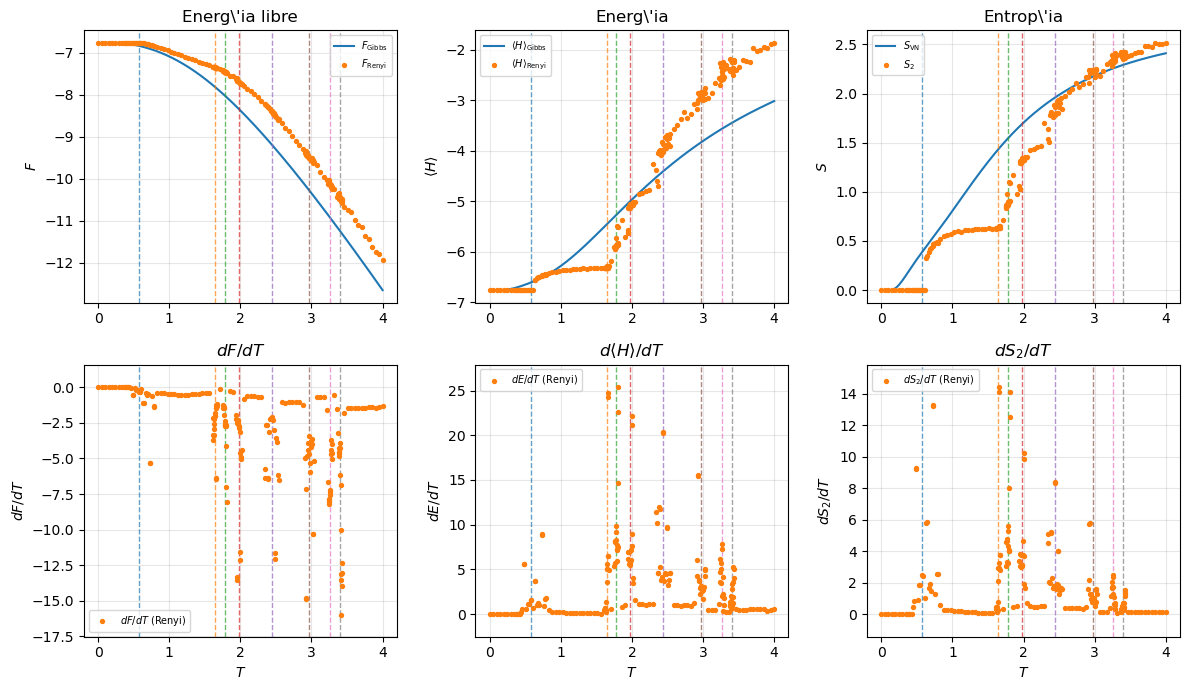

In [5]:
save = False
if save:
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
    })

    def save_fig(fig, name, subdir="plots/MRE"):
        base = os.path.join("..", subdir)
        os.makedirs(base, exist_ok=True)
        for ext in ("pgf", "pdf"):
            fig.savefig(os.path.join(base, f"{name}.{ext}"), bbox_inches="tight")
        print(f"Guardado: {base}/{name}.[pgf|pdf]")

def set_ylim_robust(ax, data_arrays, percentile=97):
    all_vals = np.concatenate([np.array(d).flatten() for d in data_arrays])
    all_vals = all_vals[np.isfinite(all_vals)]
    vmin = np.percentile(all_vals, 100 - percentile)
    vmax = np.percentile(all_vals, percentile)
    margin = 0.1 * (vmax - vmin)
    ax.set_ylim(vmin - margin, vmax + margin)

def smooth_and_diff(y, x, window=20):
    y_smooth = uniform_filter1d(np.array(y, dtype=float), size=window, mode='nearest')
    return np.gradient(y_smooth, x)

# --- Diagonalización y ensemble canónico ---
H_matrix = H_system.to_dense()
eigvals, eigvecs = np.linalg.eigh(H_matrix)

def compute_jump_temperatures(evals, tol=1e-10):
    unique_evals = []
    for e in evals:
        if not unique_evals or abs(e - unique_evals[-1]) > tol:
            unique_evals.append(e)
    unique_evals = np.array(unique_evals)
    T_jumps = []
    for n in range(1, len(unique_evals)):
        weights = unique_evals[n] - unique_evals[:n]
        E_bar = np.dot(unique_evals[:n], weights) / weights.sum()
        T_jumps.append((unique_evals[n] - E_bar) / 2)
    return np.array(T_jumps)

def canonical_ensemble(eigvals, eigvecs, T):
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)
    pops = np.exp(log_pops)
    pops /= pops.sum()
    energy = np.sum(pops * eigvals)
    mask = pops > 1e-15
    S_VN = -np.sum(pops[mask] * np.log(pops[mask]))
    return energy - T * S_VN, energy, S_VN

temperatures = np.linspace(0.05, 4, 200)
F_arr, E_arr, S_arr = np.array([canonical_ensemble(eigvals, eigvecs, T) for T in temperatures]).T

T_jumps = compute_jump_temperatures(eigvals)
T_jumps_visible = T_jumps[T_jumps <= temperatures[-1]]
cmap = plt.cm.tab10

def add_jump_lines(ax):
    for i, Tn in enumerate(T_jumps_visible):
        ax.axvline(Tn, color=cmap(i % 10), lw=1.0, ls='--', alpha=0.7)

SMOOTH_WINDOW = 20
PERCENTILE    = 97

dF_dT_renyi = smooth_and_diff(free_energy_results, T_array, window=SMOOTH_WINDOW)
dE_dT_renyi = smooth_and_diff(energy_results,      T_array, window=SMOOTH_WINDOW)
dS_dT_renyi = smooth_and_diff(entropy_results,     T_array, window=SMOOTH_WINDOW)

# --- Plot 2x3 ---
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Fila superior: valores
axes[0,0].plot(temperatures, F_arr, color='C0', label=r'$F_\mathrm{Gibbs}$')
axes[0,0].scatter(T_array, free_energy_results, color='C1', s=8, zorder=3,
                  label=r'$F_\mathrm{Renyi}$')
add_jump_lines(axes[0,0])
axes[0,0].set_ylabel(r'$F$'); axes[0,0].set_title(r'Energ\'ia libre')
axes[0,0].legend(fontsize=7); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(temperatures, E_arr, color='C0', label=r'$\langle H\rangle_\mathrm{Gibbs}$')
axes[0,1].scatter(T_array, energy_results, color='C1', s=8, zorder=3,
                  label=r'$\langle H\rangle_\mathrm{Renyi}$')
add_jump_lines(axes[0,1])
axes[0,1].set_ylabel(r'$\langle H\rangle$'); axes[0,1].set_title(r'Energ\'ia')
axes[0,1].legend(fontsize=7); axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(temperatures, S_arr, color='C0', label=r'$S_\mathrm{VN}$')
axes[0,2].scatter(T_array, entropy_results, color='C1', s=8, zorder=3,
                  label=r'$S_2$')
add_jump_lines(axes[0,2])
axes[0,2].set_ylabel(r'$S$'); axes[0,2].set_title(r'Entrop\'ia')
axes[0,2].legend(fontsize=7); axes[0,2].grid(True, alpha=0.3)

# Fila inferior: solo derivada Rényi
axes[1,0].scatter(T_array, dF_dT_renyi, color='C1', s=8, zorder=3,
                  label=r'$dF/dT\ \mathrm{(Renyi)}$')
add_jump_lines(axes[1,0])
set_ylim_robust(axes[1,0], [dF_dT_renyi], percentile=PERCENTILE)
axes[1,0].set_xlabel(r'$T$'); axes[1,0].set_ylabel(r'$dF/dT$')
axes[1,0].set_title(r'$dF/dT$'); axes[1,0].legend(fontsize=7); axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(T_array, dE_dT_renyi, color='C1', s=8, zorder=3,
                  label=r'$dE/dT\ \mathrm{(Renyi)}$')
add_jump_lines(axes[1,1])
set_ylim_robust(axes[1,1], [dE_dT_renyi], percentile=PERCENTILE)
axes[1,1].set_xlabel(r'$T$'); axes[1,1].set_ylabel(r'$dE/dT$')
axes[1,1].set_title(r'$d\langle H\rangle/dT$'); axes[1,1].legend(fontsize=7); axes[1,1].grid(True, alpha=0.3)

axes[1,2].scatter(T_array, dS_dT_renyi, color='C1', s=8, zorder=3,
                  label=r'$dS_2/dT\ \mathrm{(Renyi)}$')
add_jump_lines(axes[1,2])
set_ylim_robust(axes[1,2], [dS_dT_renyi], percentile=PERCENTILE)
axes[1,2].set_xlabel(r'$T$'); axes[1,2].set_ylabel(r'$dS_2/dT$')
axes[1,2].set_title(r'$dS_2/dT$'); axes[1,2].legend(fontsize=7); axes[1,2].grid(True, alpha=0.3)

fig.tight_layout()
if save:
    save_fig(fig, f"F_E_S_N{N}")
else: 
    plt.show()

In [6]:
def check_temperatures(N):
    data_file = f"../data/N{N}/results_N{N}_vs_T.json"
    with open(data_file, "r") as f:
        data = json.load(f)
    T_list = data["T"]
    return np.array(T_list)

def load_params(N, T, vstate):
    data_file = f"../data/N{N}/results_N{N}_vs_T.json"
    with open(data_file, "r") as f:
        data = json.load(f)
    T_list = data["T"]
    # buscar T más cercana
    idx = int(np.argmin(np.abs(np.array(T_list) - T)))
    file_idx = data["param_index"][idx]
    filename = f"../data/N{N}/params/params_{file_idx:04d}.msgpack"
    with open(filename, "rb") as f:
        params = serialization.from_bytes(vstate.parameters, f.read())
    vstate.parameters = params

def canonical_expectation(O, T, eigvals, eigvecs):
    """
    Expectation value <O> en el ensemble canónico a temperatura T.

    Parámetros
    ----------
    O : NetKet operator
    T : float
    eigvals : ndarray
    eigvecs : ndarray

    Returns
    -------
    float
    """

    # convertir operador a matriz densa
    O_matrix = O.to_dense()

    # poblaciones de Boltzmann (estables numéricamente)
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)

    pops = np.exp(log_pops)
    pops /= pops.sum()

    # <n|O|n>
    O_diag = np.einsum(
        "ij,ji->i",
        np.conj(eigvecs.T),
        O_matrix @ eigvecs,
    )

    # promedio térmico
    return np.sum(pops * O_diag).real

def renyi_expectation(O, vstate):
    """Expectation value <O> en el ensemble de Rényi."""
    return float(vstate.expect(O).mean.real)

Procesando temperaturas: 100%|██████████| 201/201 [00:48<00:00,  4.14it/s]


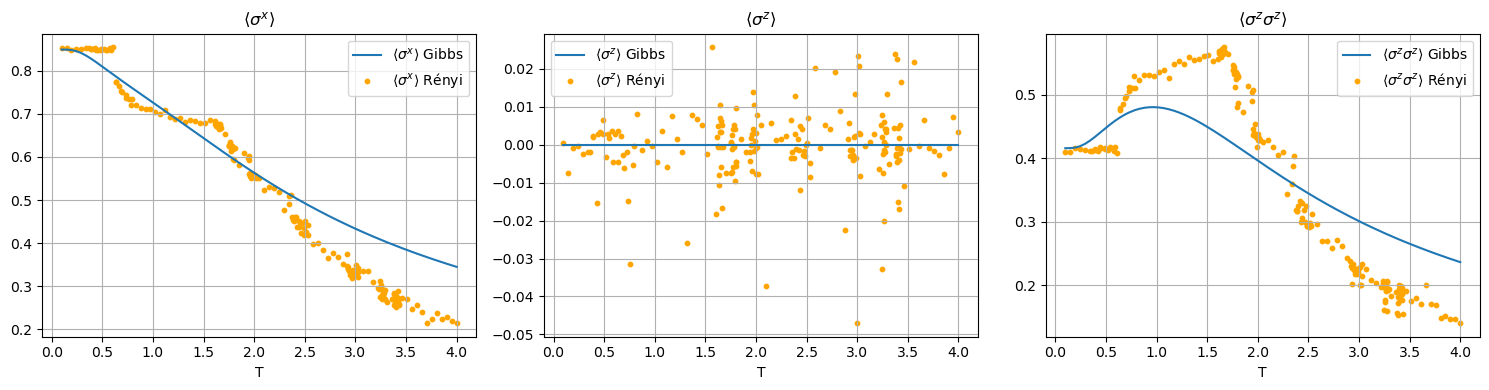

In [7]:
# Observables locales del sistema
O_x = sum(sigmax(hi_system, i) for i in range(N)) / N   # <σˣ> medio
O_z = sum(sigmaz(hi_system, i) for i in range(N)) / N   # <σᶻ> medio
O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i+1) % N) 
           for i in range(N)) / N                         # <σᶻσᶻ> medio

# Mismo operador pero en el hilbert extendido para el vstate
O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
O_z_ext = sum(sigmaz(hi_extended, i) for i in range(N)) / N
O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i+1) % N)
               for i in range(N)) / N

sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960)

T_array_compare = check_temperatures(N)

renyi_sx, renyi_sz, renyi_szz = [], [], []
gibbs_sx, gibbs_sz, gibbs_szz = [], [], []

T_filtradas = [T for T in T_array_compare if T >= 0.05]
for T in tqdm(T_filtradas, desc=f"Procesando temperaturas"):
    # Rényi: cargar parámetros y calcular
    load_params(N, T, vstate)
    renyi_sx.append(renyi_expectation(O_x_ext, vstate))
    renyi_sz.append(renyi_expectation(O_z_ext, vstate))
    renyi_szz.append(renyi_expectation(O_zz_ext, vstate))

    # Gibbs exacto
    gibbs_sx.append(canonical_expectation(O_x, T, eigvals, eigvecs))
    gibbs_sz.append(canonical_expectation(O_z, T, eigvals, eigvecs))
    gibbs_szz.append(canonical_expectation(O_zz, T, eigvals, eigvecs))

T_plot = T_array_compare[T_array_compare >= 0.05]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(T_plot, gibbs_sx, label=r'$\langle\sigma^x\rangle$ Gibbs')
axes[0].scatter(T_plot, renyi_sx, s=10, color='orange', label=r'$\langle\sigma^x\rangle$ Rényi')
axes[0].set_xlabel('T'); axes[0].set_title(r'$\langle\sigma^x\rangle$')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(T_plot, gibbs_sz, label=r'$\langle\sigma^z\rangle$ Gibbs')
axes[1].scatter(T_plot, renyi_sz, s=10, color='orange', label=r'$\langle\sigma^z\rangle$ Rényi')
axes[1].set_xlabel('T'); axes[1].set_title(r'$\langle\sigma^z\rangle$')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(T_plot, gibbs_szz, label=r'$\langle\sigma^z\sigma^z\rangle$ Gibbs')
axes[2].scatter(T_plot, renyi_szz, s=10, color='orange', label=r'$\langle\sigma^z\sigma^z\rangle$ Rényi')
axes[2].set_xlabel('T'); axes[2].set_title(r'$\langle\sigma^z\sigma^z\rangle$')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()


Procesando N = 12


N=12: 100%|██████████| 40/40 [01:54<00:00,  2.86s/it]



Procesando N = 20


N=20: 100%|██████████| 40/40 [00:15<00:00,  2.54it/s]



Procesando N = 100


N=100: 100%|██████████| 11/11 [04:30<00:00, 24.64s/it]


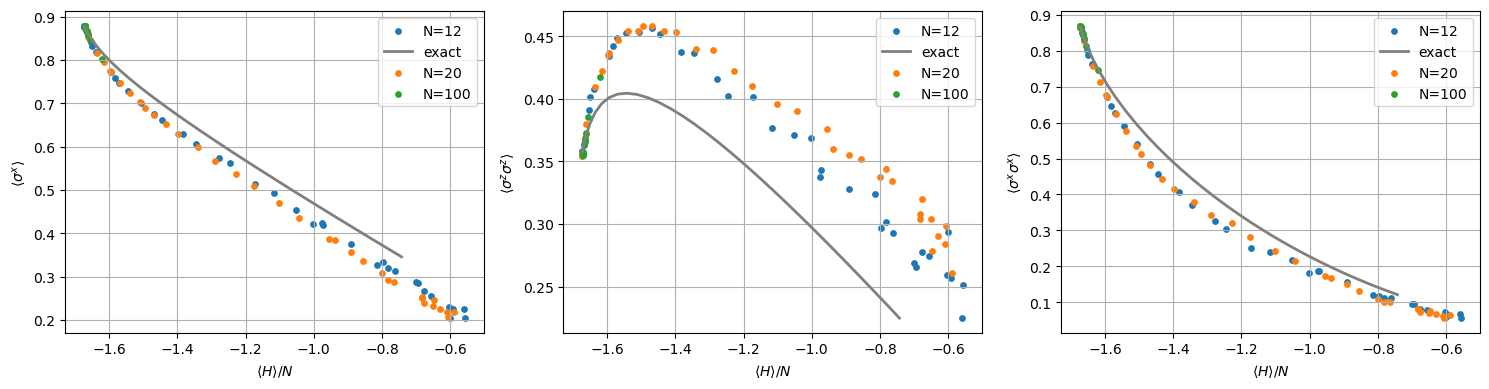

In [11]:
N_list = [12, 20, 100]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  

exact_drawn = True

for N in N_list:
    T_array = check_temperatures(N)
    T_array = T_array[T_array >= 0.05]
    if N == 12:
        exact_drawn = False
    print(f"\nProcesando N = {N}")

    # Hilbert spaces
    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)
    
    # Hamiltonianos
    H_system, H_extended = hamiltonian_system_and_extended(Gamma, V, N, hi_system, hi_extended)

    # diagonalización exacta
    if not exact_drawn:
        H_matrix = H_system.to_dense()
        eigvals, eigvecs = np.linalg.eigh(H_matrix)

    # Observables
    O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N) for i in range(N)) / N
    O_xx = sum(sigmax(hi_system, i) @ sigmax(hi_system, (i + 1) % N) for i in range(N)) / N  
    
    O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
    O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N) for i in range(N)) / N
    O_xx_ext = sum(sigmax(hi_extended, i) @ sigmax(hi_extended, (i + 1) % N) for i in range(N)) / N 

    # Vstate
    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
    if N>40:
        vstate.chunk_size = 256*4


    # Arrays resultados
    energies_renyi = []
    sx_renyi = []
    szz_renyi = []
    sxx_renyi = []  
    energies_exact = []
    sx_exact = []
    szz_exact = []
    sxx_exact = []  

    # Loop en temperatura
    for T in tqdm(T_array, desc=f"N={N}"):
        # Rényi
        load_params(N, T, vstate)
        E = vstate.expect(H_extended).mean
        e_density = E / N
        mx = vstate.expect(O_x_ext).mean
        corr_zz = vstate.expect(O_zz_ext).mean
        corr_xx = vstate.expect(O_xx_ext).mean 
        energies_renyi.append(e_density)
        sx_renyi.append(mx)
        szz_renyi.append(corr_zz)
        sxx_renyi.append(corr_xx)  

        # Exacto
        if not exact_drawn:
            beta = 1.0 / T
            weights = np.exp(-beta * eigvals)
            Z = np.sum(weights)
            E_exact = np.sum(eigvals * weights) / Z
            e_density_exact = E_exact / N
            mx_exact = canonical_expectation(O_x, T, eigvals, eigvecs)
            corr_zz_exact = canonical_expectation(O_zz, T, eigvals, eigvecs)
            corr_xx_exact = canonical_expectation(O_xx, T, eigvals, eigvecs)  
            energies_exact.append(e_density_exact)
            sx_exact.append(mx_exact)
            szz_exact.append(corr_zz_exact)
            sxx_exact.append(corr_xx_exact)  

    # Plot Rényi
    axes[0].scatter(energies_renyi, sx_renyi, s=15, label=f"N={N}")
    axes[1].scatter(energies_renyi, szz_renyi, s=15, label=f"N={N}")
    axes[2].scatter(energies_renyi, sxx_renyi, s=15, label=f"N={N}")  

    # Plot exacto (una vez)
    if not exact_drawn:
        axes[0].plot(energies_exact, sx_exact, color="gray", linewidth=2, label="exact")
        axes[1].plot(energies_exact, szz_exact, color="gray", linewidth=2, label="exact")
        axes[2].plot(energies_exact, sxx_exact, color="gray", linewidth=2, label="exact") 
        exact_drawn = True


# Formato final
axes[0].set_xlabel(r"$\langle H \rangle / N$")
axes[1].set_xlabel(r"$\langle H \rangle / N$")
axes[2].set_xlabel(r"$\langle H \rangle / N$")

axes[0].set_ylabel(r"$\langle \sigma^x \rangle$")
axes[1].set_ylabel(r"$\langle \sigma^z \sigma^z \rangle$")
axes[2].set_ylabel(r"$\langle \sigma^x \sigma^x \rangle$") 

for ax in axes:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


Procesando N = 20


N=20: 100%|██████████| 40/40 [00:11<00:00,  3.53it/s]



Procesando N = 100


N=100: 100%|██████████| 11/11 [04:37<00:00, 25.21s/it]


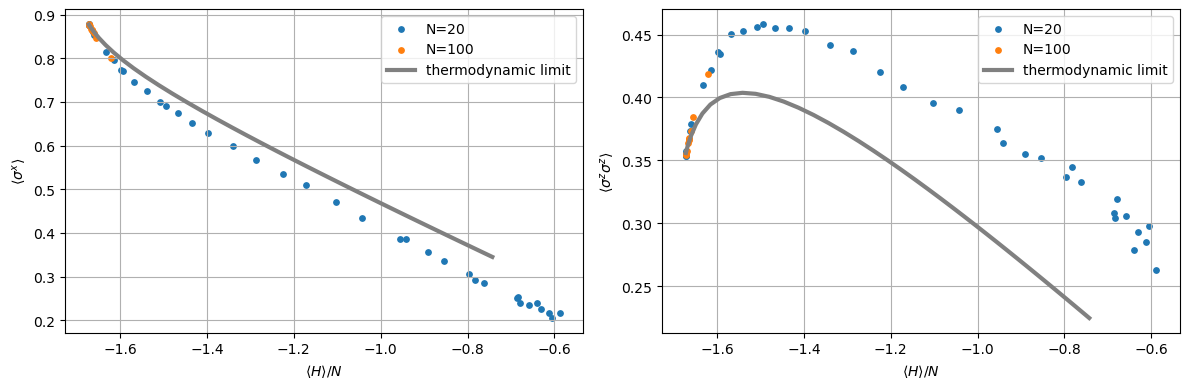

In [9]:
N_list = [20, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Límite termodinámico
Nk = 4000
k = np.linspace(0, np.pi, Nk)
dk = np.pi / Nk

J = abs(V)
h = abs(Gamma)

energies_td = []
sx_td = []         
szz_td = []

for T in T_array:
    beta = 1.0 / T
    eps_k = 2 * np.sqrt(J**2 + h**2 - 2 * J * h * np.cos(k))
    tanh_term = np.tanh(beta * eps_k / 2)
    # Energía por sitio 
    e = - np.sum((eps_k / 2) * tanh_term) * dk / np.pi
    # <σx>
    mx = np.sum((h - J * np.cos(k)) / eps_k * tanh_term) * dk / np.pi
    # <σz σz>
    corr = np.sum((J - h * np.cos(k))/eps_k* tanh_term) * dk / np.pi
    energies_td.append(e)
    szz_td.append(corr*2)
    sx_td.append(mx*2)   

# Loop en N

for N in N_list:
    T_array = check_temperatures(N)
    T_array = T_array[T_array >= 0.05]
    print(f"\nProcesando N = {N}")

    # Hilbert spaces
    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)

    # Hamiltonianos
    H_system, H_extended = hamiltonian_system_and_extended(Gamma,V,N,hi_system,hi_extended)

    # Observables
    O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N) for i in range(N)) / N
    O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
    O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N) for i in range(N)) / N

    # Vstate
    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
    if N>40:
        vstate.chunk_size = 256*4

    energies_renyi = []
    sx_renyi = []
    szz_renyi = []

    # Loop en temperatura
    for T in tqdm(T_array, desc=f"N={N}"):
        load_params(N, T, vstate)
        if N>50:
            vstate.chunk_size = 256
        E = vstate.expect(H_extended).mean
        e_density = E / N
        mx = vstate.expect(O_x_ext).mean
        corr = vstate.expect(O_zz_ext).mean
        energies_renyi.append(e_density)
        sx_renyi.append(mx)
        szz_renyi.append(corr)

    # Plot Rényi
    axes[0].scatter(energies_renyi, sx_renyi, s=15, label=f"N={N}")
    axes[1].scatter(energies_renyi, szz_renyi, s=15, label=f"N={N}")


# Plot límite termodinámico
axes[0].plot(energies_td, sx_td, color="gray", linewidth=3, label="thermodynamic limit")
axes[1].plot(energies_td, szz_td, color="gray", linewidth=3, label="thermodynamic limit")


axes[0].set_xlabel(r"$\langle H \rangle / N$")
axes[1].set_xlabel(r"$\langle H \rangle / N$")

axes[0].set_ylabel(r"$\langle \sigma^x \rangle$")
axes[1].set_ylabel(r"$\langle \sigma^z \sigma^z \rangle$")

axes[0].grid(True)
axes[1].grid(True)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()